# DeepLense: Physics Informed Efficient Net B2 Model Training and Evaluation Results

This notebook shows the results obtained after training the model. I have shown the config used and the results obtained. A demo for how things are setup a bit under the hood is availabe in "notebooks/common task 1/training.ipynb"
Instructions on updating the config and training a model of your choice is available in the Github repository's README.md

In [ ]:
import os
import sys
from pathlib import Path

print(f"Original CWD: {os.getcwd()}")

os.chdir("../..")
sys.path.append(os.getcwd())

print(f"New CWD: {os.getcwd()}")

Original CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion\notebooks\Task 2 - Physics Informed Classification
New CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion


In [ ]:
import os
import torch
import mlflow
import matplotlib.pyplot as plt
from hydra import initialize, compose
from IPython.display import Image, display

import warnings

warnings.filterwarnings("ignore")

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.10.0+cu126
CUDA Available: True


In [13]:
import tempfile
from IPython.display import Markdown

BEST_RUN_ID = "49a4f8f8f17842a28f223451adc518a4"

# CONFIGURATION
CONFIG_ARTIFACT_PATH = "config/config.yaml"

client = mlflow.tracking.MlflowClient()

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        # Download the config file directly from MLflow's artifact store
        local_config_path = client.download_artifacts(
            BEST_RUN_ID, CONFIG_ARTIFACT_PATH, tmp_dir
        )

        # Read the YAML text
        with open(local_config_path, "r") as f:
            config_text = f.read()

        # Render it beautifully in Jupyter with syntax highlighting
        display(
            Markdown(
                f"### Experiment Configuration (Run ID: `{BEST_RUN_ID}`)\n"
                f"```yaml\n{config_text}\n```"
            )
        )

    except Exception as e:
        print(f"Could not load the configuration artifact. Error: {e}")

### Experiment Configuration (Run ID: `49a4f8f8f17842a28f223451adc518a4`)
```yaml
dataset:
  name: deeplense_classify
  image_size: 150
  batch_size: 64
  data_root: datasets/deeplense_classify/dataset
model:
  name: pinn_efficient_net_b2
  type: classifier
  backbone:
    pretrained: true
    num_classes: 3
    in_channels: 2
  physics_module:
    in_channels: 1
    estimator_channels:
    - 8
    - 16
  metrics:
    acc:
      name: accuracy
    roc_auc:
      name: roc_auc
    roc:
      name: roc
training:
  epochs: 10
  lr: 0.0002
  ema_decay: 0.9999
  validate_every_n_epochs: 1
sampling:
  num_images: 16
  sample_every_n_epochs: 10
device: cuda
experiment_name: pinn_efficient_net_b2_deeplense_classify
seed: 42
resume_from_run_id: null

```

Fetching Final Results from MLflow Run: 49a4f8f8f17842a28f223451adc518a4

Final Validation ROC AUC: 0.9582
Final Validation Accuracy: 0.8604



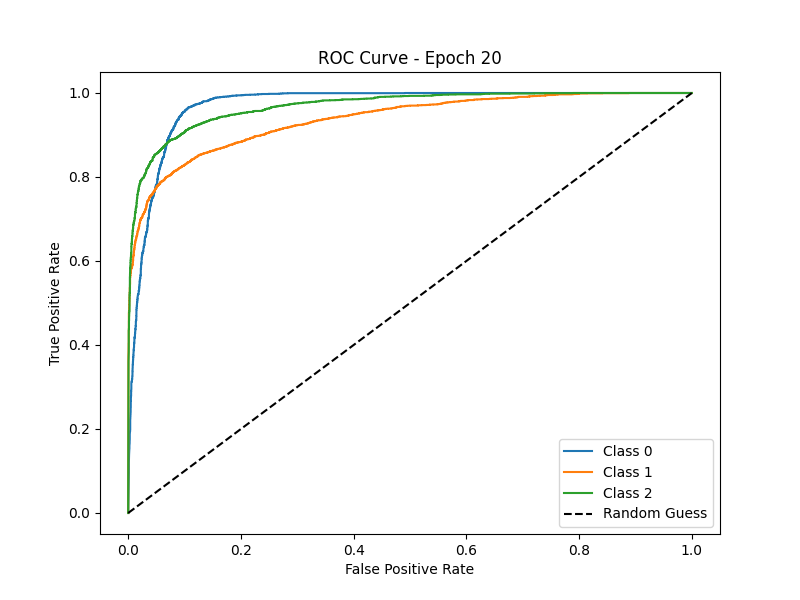

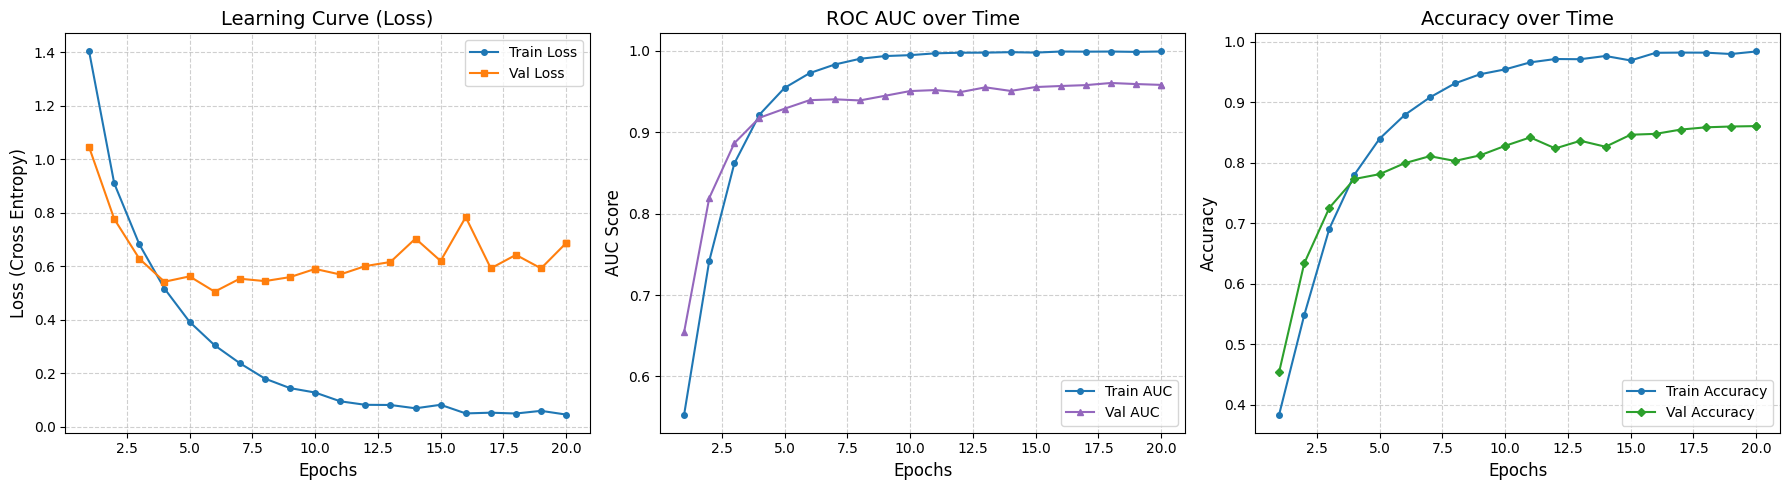

In [15]:
print(f"Fetching Final Results from MLflow Run: {BEST_RUN_ID}\n")


def fetch_metric(metric_name):
    try:
        history = client.get_metric_history(BEST_RUN_ID, metric_name)
        return [m.step for m in history], [m.value for m in history]
    except Exception:
        return [], []


# Fetch metrics
epochs_tl, train_loss = fetch_metric("avg_loss")
epochs_vl, val_loss = fetch_metric("val_avg_loss")

epochs_ta, train_auc = fetch_metric("roc_auc")
epochs_va, val_auc = fetch_metric("val_roc_auc")

epochs_tacc, train_acc = fetch_metric("accuracy")
epochs_vacc, val_acc = fetch_metric("val_accuracy")

final_auc = val_auc[-1] if val_auc else "N/A"
final_acc = val_acc[-1] if val_acc else "N/A"

print(f"Final Validation ROC AUC: {final_auc:.4f}")
if final_acc != "N/A":
    print(f"Final Validation Accuracy: {final_acc:.4f}\n")

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        artifact_path = "validation_metrics/roc_curve_epoch_20.png"
        local_path = client.download_artifacts(BEST_RUN_ID, artifact_path, tmp_dir)
        display(Image(filename=local_path))
    except Exception as e:
        print(f"Could not load the final ROC curve artifact: {e}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss
if train_loss and val_loss:
    axes[0].plot(
        epochs_tl,
        train_loss,
        label="Train Loss",
        color="tab:blue",
        marker="o",
        markersize=4,
    )
    axes[0].plot(
        epochs_vl,
        val_loss,
        label="Val Loss",
        color="tab:orange",
        marker="s",
        markersize=4,
    )
    axes[0].set_title("Learning Curve (Loss)", fontsize=14)
    axes[0].set_xlabel("Epochs", fontsize=12)
    axes[0].set_ylabel("Loss (Cross Entropy)", fontsize=12)
    axes[0].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: ROC AUC
if train_auc and val_auc:
    axes[1].plot(
        epochs_ta,
        train_auc,
        label="Train AUC",
        color="tab:blue",
        marker="o",
        markersize=4,
    )
    axes[1].plot(
        epochs_va,
        val_auc,
        label="Val AUC",
        color="tab:purple",
        marker="^",
        markersize=5,
    )
    axes[1].set_title("ROC AUC over Time", fontsize=14)
    axes[1].set_xlabel("Epochs", fontsize=12)
    axes[1].set_ylabel("AUC Score", fontsize=12)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot 3: Accuracy
if train_acc and val_acc:
    axes[2].plot(
        epochs_tacc,
        train_acc,
        label="Train Accuracy",
        color="tab:blue",
        marker="o",
        markersize=4,
    )
    axes[2].plot(
        epochs_vacc,
        val_acc,
        label="Val Accuracy",
        color="tab:green",
        marker="D",
        markersize=4,
    )
    axes[2].set_title("Accuracy over Time", fontsize=14)
    axes[2].set_xlabel("Epochs", fontsize=12)
    axes[2].set_ylabel("Accuracy", fontsize=12)
    axes[2].legend(loc="lower right")
    axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()